# Análisis de Datos Educativos y Socioeconómicos

**Pontificia Universidad Javeriana**

**Integrantes:**
- Diego Fernando zabala 
- Juan Santiago Mendez
- Juan Martin Trejos
- Juan Ordoñez

**Descripción:**
Análisis de la relación entre resultados Saber 11 y factores educativos y socioeconómicos a nivel municipal.

##  Datos del Ministerio de Educación (MEN)

Carga y procesamiento de estadísticas educativas por municipio.

Se importan las librerías necesarias para la lectura, manipulación y exploración de los datos.

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Se realiza una selección inicial de atributos relevantes para el análisis, con el fin de conservar únicamente las variables de interés del estudio.

In [0]:
import pandas as pd

# Ruta del archivo MEN
ruta_men = "/Workspace/Users/diegozabalag@gmail.com/ESTADISTICO/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260406.csv"

# Cargar archivo original
df_men = pd.read_csv(ruta_men, low_memory=False)

print("Dimensiones originales:", df_men.shape)

# Columnas que van a usar
columnas_men = [
    "AÑO",
    "CÓDIGO_MUNICIPIO",
    "TASA_MATRICULACIÓN_5_16",
    "COBERTURA_NETA",
    "COBERTURA_NETA_PRIMARIA",
    "COBERTURA_NETA_SECUNDARIA",
    "COBERTURA_NETA_MEDIA",
    "SEDES_CONECTADAS_A_INTERNET",
    "DESERCIÓN",
    "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA",
    "DESERCIÓN_MEDIA",
    "APROBACIÓN",
    "APROBACIÓN_PRIMARIA",
    "APROBACIÓN_SECUNDARIA",
    "APROBACIÓN_MEDIA",
    "REPROBACIÓN",
    "REPROBACIÓN_PRIMARIA",
    "REPROBACIÓN_SECUNDARIA",
    "REPROBACIÓN_MEDIA",
    "REPITENCIA",
    "REPITENCIA_PRIMARIA",
    "REPITENCIA_SECUNDARIA",
    "REPITENCIA_MEDIA"
]

# Validar cuáles existen
columnas_presentes = [c for c in columnas_men if c in df_men.columns]
columnas_faltantes = [c for c in columnas_men if c not in df_men.columns]

print("\nColumnas presentes:")
print(columnas_presentes)

print("\nColumnas faltantes:")
print(columnas_faltantes)

# Recorte
df_men = df_men[columnas_presentes].copy()

# Renombrar para dejarlo listo
df_men = df_men.rename(columns={
    "AÑO": "anio",
    "CÓDIGO_MUNICIPIO": "cod_mpio",
    "TASA_MATRICULACIÓN_5_16": "tasa_matriculacion_5_16",
    "COBERTURA_NETA": "cobertura_neta",
    "COBERTURA_NETA_PRIMARIA": "cobertura_neta_primaria",
    "COBERTURA_NETA_SECUNDARIA": "cobertura_neta_secundaria",
    "COBERTURA_NETA_MEDIA": "cobertura_neta_media",
    "SEDES_CONECTADAS_A_INTERNET": "sedes_conectadas_internet",
    "DESERCIÓN": "desercion",
    "DESERCIÓN_PRIMARIA": "desercion_primaria",
    "DESERCIÓN_SECUNDARIA": "desercion_secundaria",
    "DESERCIÓN_MEDIA": "desercion_media",
    "APROBACIÓN": "aprobacion",
    "APROBACIÓN_PRIMARIA": "aprobacion_primaria",
    "APROBACIÓN_SECUNDARIA": "aprobacion_secundaria",
    "APROBACIÓN_MEDIA": "aprobacion_media",
    "REPROBACIÓN": "reprobacion",
    "REPROBACIÓN_PRIMARIA": "reprobacion_primaria",
    "REPROBACIÓN_SECUNDARIA": "reprobacion_secundaria",
    "REPROBACIÓN_MEDIA": "reprobacion_media",
    "REPITENCIA": "repitencia",
    "REPITENCIA_PRIMARIA": "repitencia_primaria",
    "REPITENCIA_SECUNDARIA": "repitencia_secundaria",
    "REPITENCIA_MEDIA": "repitencia_media"
})

# Dejar tipos listos para cruce
if "cod_mpio" in df_men.columns:
    df_men["cod_mpio"] = pd.to_numeric(df_men["cod_mpio"], errors="coerce").astype("Int64")

if "anio" in df_men.columns:
    df_men["anio"] = pd.to_numeric(df_men["anio"], errors="coerce").astype("Int64")

municipios_objetivo = [11001, 76113, 15104]
df_men = df_men[df_men["cod_mpio"].isin(municipios_objetivo)].copy()


print("\nDimensiones finales:", df_men.shape)
print("\nColumnas finales:")
print(df_men.columns.tolist())

display(df_men.head())

Dimensiones originales: (15707, 41)

Columnas presentes:
['AÑO', 'CÓDIGO_MUNICIPIO', 'TASA_MATRICULACIÓN_5_16', 'COBERTURA_NETA', 'COBERTURA_NETA_PRIMARIA', 'COBERTURA_NETA_SECUNDARIA', 'COBERTURA_NETA_MEDIA', 'SEDES_CONECTADAS_A_INTERNET', 'DESERCIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'APROBACIÓN_PRIMARIA', 'APROBACIÓN_SECUNDARIA', 'APROBACIÓN_MEDIA', 'REPROBACIÓN', 'REPROBACIÓN_PRIMARIA', 'REPROBACIÓN_SECUNDARIA', 'REPROBACIÓN_MEDIA', 'REPITENCIA', 'REPITENCIA_PRIMARIA', 'REPITENCIA_SECUNDARIA', 'REPITENCIA_MEDIA']

Columnas faltantes:
[]

Dimensiones finales: (42, 24)

Columnas finales:
['anio', 'cod_mpio', 'tasa_matriculacion_5_16', 'cobertura_neta', 'cobertura_neta_primaria', 'cobertura_neta_secundaria', 'cobertura_neta_media', 'sedes_conectadas_internet', 'desercion', 'desercion_primaria', 'desercion_secundaria', 'desercion_media', 'aprobacion', 'aprobacion_primaria', 'aprobacion_secundaria', 'aprobacion_media', 'reprobacion', 'reprob

anio,cod_mpio,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,sedes_conectadas_internet,desercion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_primaria,repitencia_secundaria,repitencia_media
2024,76113,"67,3%","67,28%","66,13%","57,28%","42,46%",null,"5,56%","4,39%","6,52%","5,76%","90,1%","92,32%","86,54%","91,01%","4,34%","3,29%","6,93%","3,23%","7,84%","6,91%","11,2%","5,28%"
2024,15104,"66,73%","66,73%","63,55%","59,48%","62,79%",null,"2,01%","1,43%","2,48%","2,22%","95,84%","96,42%","93,8%","97,78%","2,15%","2,15%","3,72%",0%,"3,44%","1,79%","6,2%","1,48%"
2024,11001,"91,02%","90,6%","85,03%","84,68%","65,32%",null,"2,49%","2,37%","2,77%",2%,"90,6%","92,98%","85,76%","92,37%","6,92%","4,65%","11,48%","5,63%","8,16%","7,49%","11,98%","3,75%"
2023,11001,"92,9%","92,4%","86,97%","86,48%","64,42%",null,"2,82%","2,69%","3,17%","2,16%","89,4%","91,87%","84,26%","91,35%","7,78%","5,44%","12,57%","6,5%","7,55%","7,11%","10,98%","3,2%"
2023,15104,"70,92%","70,92%","61,95%","61,05%","65,9%",null,2%,"0,72%","3,01%","2,13%",98%,"99,28%","96,99%","97,87%",0%,0%,0%,0%,"6,41%","3,25%","12,41%","3,55%"


## Procesamiento de datos del ICFES


Se cargan los archivos del ICFES correspondientes a los municipios de Bogotá, Bugalagrande y Sogamoso, previamente validados y seleccionados para el análisis.

In [0]:
import pandas as pd

ruta_base_icfes = "/Workspace/Users/diegozabalag@gmail.com/ICFES"

ruta_bog = f"{ruta_base_icfes}/icfes_recortado.csv"
ruta_bug = f"{ruta_base_icfes}/bugalagrande_Resultados_únicos_Saber_11_20260406.csv"
ruta_sog = f"{ruta_base_icfes}/sogamoso_Resultados_únicos_Saber_11_20260406.csv"

df_bog = pd.read_csv(ruta_bog, low_memory=False)
df_bug = pd.read_csv(ruta_bug, low_memory=False)
df_sog = pd.read_csv(ruta_sog, low_memory=False)

print("BOG:", df_bog.shape)
print("BUG:", df_bug.shape)
print("SOG:", df_sog.shape)

BOG: (1134943, 18)
BUG: (3248, 51)
SOG: (37401, 51)


Se toma el dataset de Bogotá como referencia para definir la estructura de columnas que se utilizará en los demás conjuntos de datos.

In [0]:
columnas_plantilla = df_bog.columns.tolist()

print("Columnas plantilla (icfes_recortado):")
print(columnas_plantilla)
print("\nTotal columnas plantilla:", len(columnas_plantilla))

Columnas plantilla (icfes_recortado):
['PERIODO', 'COLE_BILINGUE', 'COLE_MCPIO_UBICACION', 'ESTU_COD_RESIDE_MCPIO', 'ESTU_ESTUDIANTE', 'ESTU_MCPIO_RESIDE', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA', 'PUNT_GLOBAL']

Total columnas plantilla: 18


Se comparan los datasets de Bugalagrande y Sogamoso contra la plantilla de Bogotá para identificar columnas faltantes y adicionales.

In [0]:
# Pasar columnas de BUG y SOG a minúscula
df_bug.columns = [c.upper() for c in df_bug.columns]
df_sog.columns = [c.upper() for c in df_sog.columns]

# Volver a revisar contra la plantilla
faltan_bug = [c for c in columnas_plantilla if c not in df_bug.columns]
faltan_sog = [c for c in columnas_plantilla if c not in df_sog.columns]

sobran_bug = [c for c in df_bug.columns if c not in columnas_plantilla]
sobran_sog = [c for c in df_sog.columns if c not in columnas_plantilla]

print("Faltan en BUG:")
print(faltan_bug)

print("\nFaltan en SOG:")
print(faltan_sog)

print("\nSobran en BUG:")
print(sobran_bug)

print("\nSobran en SOG:")
print(sobran_sog)

Faltan en BUG:
[]

Faltan en SOG:
[]

Sobran en BUG:
['ESTU_TIPODOCUMENTO', 'ESTU_CONSECUTIVO', 'COLE_AREA_UBICACION', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_COD_DANE_ESTABLECIMIENTO', 'COLE_COD_DANE_SEDE', 'COLE_COD_DEPTO_UBICACION', 'COLE_COD_MCPIO_UBICACION', 'COLE_CODIGO_ICFES', 'COLE_DEPTO_UBICACION', 'COLE_GENERO', 'COLE_JORNADA', 'COLE_NATURALEZA', 'COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_NOMBRE_SEDE', 'COLE_SEDE_PRINCIPAL', 'ESTU_COD_DEPTO_PRESENTACION', 'ESTU_COD_MCPIO_PRESENTACION', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_DEPTO_PRESENTACION', 'ESTU_DEPTO_RESIDE', 'ESTU_ESTADOINVESTIGACION', 'ESTU_FECHANACIMIENTO', 'ESTU_GENERO', 'ESTU_MCPIO_PRESENTACION', 'ESTU_NACIONALIDAD', 'ESTU_PAIS_RESIDE', 'ESTU_PRIVADO_LIBERTAD', 'FAMI_CUARTOSHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENELAVADORA', 'DESEMP_INGLES']

Sobran en SOG:
['ESTU_TIPODOCUMENTO', 'ESTU_CONSECUTIVO', 'COLE_AREA_UBICACION', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_COD_DANE_ESTABLECIMIENTO', 'COLE_COD_DANE_SEDE', 'COLE_COD_DEPT

Se estandariza la estructura de los datasets, agregando columnas faltantes y reordenando según la plantilla definida.

In [0]:
# BLOQUE 4 — Alinear columnas de BUG y SOG con la plantilla de BOG

for col in columnas_plantilla:
    if col not in df_bug.columns:
        df_bug[col] = pd.NA

for col in columnas_plantilla:
    if col not in df_sog.columns:
        df_sog[col] = pd.NA

df_bug = df_bug[columnas_plantilla].copy()
df_sog = df_sog[columnas_plantilla].copy()

print("BUG igual a plantilla:", df_bug.columns.tolist() == columnas_plantilla)
print("SOG igual a plantilla:", df_sog.columns.tolist() == columnas_plantilla)

print("BOG:", df_bog.shape)
print("BUG:", df_bug.shape)
print("SOG:", df_sog.shape)

BUG igual a plantilla: True
SOG igual a plantilla: True
BOG: (1134943, 18)
BUG: (3248, 18)
SOG: (37401, 18)


Se incorpora una variable de identificación del municipio para diferenciar los registros en el proceso de integración.

In [0]:
# BLOQUE 5 — Agregar municipio objetivo a cada dataset

df_bog["municipio_objetivo"] = "BOGOTA"
df_bug["municipio_objetivo"] = "BUGALAGRANDE"
df_sog["municipio_objetivo"] = "SOGAMOSO"

display(df_bog.head(5))
display(df_bug.head())
display(df_sog.head())

PERIODO,COLE_BILINGUE,COLE_MCPIO_UBICACION,ESTU_COD_RESIDE_MCPIO,ESTU_ESTUDIANTE,ESTU_MCPIO_RESIDE,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,municipio_objetivo
20131,N,BOGOTÁ D.C.,11001,ESTUDIANTE,BOGOTÁ D.C.,Educación profesional completa,Educación profesional completa,Estrato 6,Cuatro,Si,Si,94.0,88.0,null,null,null,null,BOGOTA
20132,N,"BOGOTÁ, D.C.",11001,ESTUDIANTE,BOGOTÁ D.C.,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,Estrato 2,Seis,No,Si,45.0,54.0,null,null,null,null,BOGOTA
20194,null,BOGOTÁ D.C.,11001,ESTUDIANTE,BOGOTÁ D.C.,Técnica o tecnológica completa,Técnica o tecnológica completa,Estrato 3,1 a 2,Si,Si,56.0,45.0,27.0,27.0,35.0,176.0,BOGOTA
20194,null,BOGOTÁ D.C.,11001,ESTUDIANTE,BOGOTÁ D.C.,Técnica o tecnológica completa,Técnica o tecnológica completa,Estrato 3,1 a 2,Si,Si,56.0,45.0,27.0,27.0,35.0,176.0,BOGOTA
20132,N,"BOGOTÁ, D.C.",11001,ESTUDIANTE,BOGOTÁ D.C.,Secundaria (Bachillerato) completa,Ninguno,Estrato 3,Dos,Si,Si,40.0,57.0,null,null,null,null,BOGOTA


PERIODO,COLE_BILINGUE,COLE_MCPIO_UBICACION,ESTU_COD_RESIDE_MCPIO,ESTU_ESTUDIANTE,ESTU_MCPIO_RESIDE,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,municipio_objetivo
20172,N,BUGALAGRANDE,76113.0,ESTUDIANTE,BUGALAGRANDE,null,null,null,7 a 8,No,null,44.0,40.0,39.0,41.0,45.0,207.0,BUGALAGRANDE
20142,N,BUGALAGRANDE,76113.0,ESTUDIANTE,BUGALAGRANDE,Secundaria (Bachillerato) completa,Ninguno,Estrato 2,Tres,No,No,42.0,45.0,57.0,44.0,52.0,245.0,BUGALAGRANDE
20142,N,BUGALAGRANDE,76113.0,ESTUDIANTE,BUGALAGRANDE,No sabe,No sabe,Estrato 2,Cuatro,No,No,53.0,58.0,51.0,52.0,54.0,268.0,BUGALAGRANDE
20162,N,BUGALAGRANDE,76113.0,ESTUDIANTE,BUGALAGRANDE,Primaria incompleta,Secundaria (Bachillerato) incompleta,Estrato 1,Cinco,No,No,35.0,51.0,29.0,47.0,40.0,206.0,BUGALAGRANDE
20122,N,BUGALAGRANDE,76113.0,ESTUDIANTE,BUGALAGRANDE,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,Cuatro,Si,Si,42.0,39.0,null,null,null,null,BUGALAGRANDE


PERIODO,COLE_BILINGUE,COLE_MCPIO_UBICACION,ESTU_COD_RESIDE_MCPIO,ESTU_ESTUDIANTE,ESTU_MCPIO_RESIDE,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,municipio_objetivo
20132,N,NOBSA,15104.0,ESTUDIANTE,BOYACÁ,Primaria completa,Primaria completa,Estrato 2,Ocho,Si,No,43.0,46.0,null,null,null,null,SOGAMOSO
20162,N,SOGAMOSO,15759.0,ESTUDIANTE,SOGAMOSO,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,Dos,Si,Si,52.0,65.0,56.0,61.0,49.0,287.0,SOGAMOSO
20172,N,SOGAMOSO,15759.0,ESTUDIANTE,SOGAMOSO,Primaria incompleta,Secundaria (Bachillerato) incompleta,Estrato 1,5 a 6,Si,Si,57.0,63.0,59.0,54.0,58.0,292.0,SOGAMOSO
20152,N,SOGAMOSO,15759.0,ESTUDIANTE,SOGAMOSO,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,Estrato 2,Tres,No,No,57.0,62.0,63.0,57.0,59.0,300.0,SOGAMOSO
20162,N,SOGAMOSO,15491.0,ESTUDIANTE,NOBSA,Técnica o tecnológica incompleta,Técnica o tecnológica completa,Estrato 2,Cinco,Si,Si,37.0,39.0,34.0,35.0,40.0,185.0,SOGAMOSO


Se reordenan las columnas para incluir la variable de municipio en una posición consistente dentro del dataset.

Se realiza la concatenación de los datasets previamente estandarizados, construyendo un único dataset consolidado del ICFES.

In [0]:
# BLOQUE 7 — Unir Bogotá, Bugalagrande y Sogamoso en un solo dataset ICFES

df_icfes = pd.concat([df_bog, df_bug, df_sog], ignore_index=True)

print("ICFES unificado:", df_icfes.shape)
display(df_icfes.head())

ICFES unificado: (1175592, 19)


PERIODO,COLE_BILINGUE,COLE_MCPIO_UBICACION,ESTU_COD_RESIDE_MCPIO,ESTU_ESTUDIANTE,ESTU_MCPIO_RESIDE,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,municipio_objetivo
20131,N,BOGOTÁ D.C.,11001.0,ESTUDIANTE,BOGOTÁ D.C.,Educación profesional completa,Educación profesional completa,Estrato 6,Cuatro,Si,Si,94.0,88.0,null,null,null,null,BOGOTA
20132,N,"BOGOTÁ, D.C.",11001.0,ESTUDIANTE,BOGOTÁ D.C.,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,Estrato 2,Seis,No,Si,45.0,54.0,null,null,null,null,BOGOTA
20194,null,BOGOTÁ D.C.,11001.0,ESTUDIANTE,BOGOTÁ D.C.,Técnica o tecnológica completa,Técnica o tecnológica completa,Estrato 3,1 a 2,Si,Si,56.0,45.0,27.0,27.0,35.0,176.0,BOGOTA
20194,null,BOGOTÁ D.C.,11001.0,ESTUDIANTE,BOGOTÁ D.C.,Técnica o tecnológica completa,Técnica o tecnológica completa,Estrato 3,1 a 2,Si,Si,56.0,45.0,27.0,27.0,35.0,176.0,BOGOTA
20132,N,"BOGOTÁ, D.C.",11001.0,ESTUDIANTE,BOGOTÁ D.C.,Secundaria (Bachillerato) completa,Ninguno,Estrato 3,Dos,Si,Si,40.0,57.0,null,null,null,null,BOGOTA


Se valida la composición del dataset unificado, verificando la distribución de registros por municipio y la estructura final de columnas.

In [0]:
# BLOQUE 8 — Validar contenido del dataset unificado

print(df_icfes["municipio_objetivo"].value_counts(dropna=False))
print("\nColumnas finales:")
print(df_icfes.columns.tolist())

municipio_objetivo
BOGOTA          1134943
SOGAMOSO          37401
BUGALAGRANDE       3248
Name: count, dtype: int64

Columnas finales:
['PERIODO', 'COLE_BILINGUE', 'COLE_MCPIO_UBICACION', 'ESTU_COD_RESIDE_MCPIO', 'ESTU_ESTUDIANTE', 'ESTU_MCPIO_RESIDE', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA', 'PUNT_GLOBAL', 'municipio_objetivo']


Se analiza la estructura del dataset, incluyendo tipos de variables y cantidad de valores nulos por columna, para evaluar la calidad de los datos.

In [0]:
# BLOQUE 11 — Revisar tipos y nulos del dataset ICFES unificado

print(df_icfes.info())

print("\nNulos por columna:")
print(df_icfes.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1175592 entries, 0 to 1175591
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   PERIODO                   1175592 non-null  int64  
 1   COLE_BILINGUE             1015312 non-null  object 
 2   COLE_MCPIO_UBICACION      1175591 non-null  object 
 3   ESTU_COD_RESIDE_MCPIO     1175343 non-null  float64
 4   ESTU_ESTUDIANTE           1175592 non-null  object 
 5   ESTU_MCPIO_RESIDE         1175343 non-null  object 
 6   FAMI_EDUCACIONMADRE       1150385 non-null  object 
 7   FAMI_EDUCACIONPADRE       1150422 non-null  object 
 8   FAMI_ESTRATOVIVIENDA      1153352 non-null  object 
 9   FAMI_PERSONASHOGAR        1162293 non-null  object 
 10  FAMI_TIENECOMPUTADOR      1158288 non-null  object 
 11  FAMI_TIENEINTERNET        1154203 non-null  object 
 12  PUNT_INGLES               1175540 non-null  float64
 13  PUNT_MATEMATICAS          1

## Datos del Sisbén

Se cargan los datasets del Sisbén correspondientes a personas y hogares para los municipios de interés, verificando su dimensión y estructura inicial.

In [0]:
# BLOQUE 1 — Cargar los 3 archivos de Sisbén

import pandas as pd

ruta_base_sisben = "/Workspace/Users/diegozabalag@gmail.com/SISBEN"

ruta_personas = f"{ruta_base_sisben}/DNP_-_Sisbén_Personas_20260407.csv"
ruta_boyaca = f"{ruta_base_sisben}/Vista_DNP-SISBEN_PERSONAS_20260406_boyaca.csv"
ruta_bug = f"{ruta_base_sisben}/Vista_Sisbén_Hogares_Municipio_Bugalagrande_20260406.csv"

df_personas = pd.read_csv(ruta_personas, low_memory=False)
df_boyaca = pd.read_csv(ruta_boyaca, low_memory=False)
df_bug = pd.read_csv(ruta_bug, low_memory=False)

print("PERSONAS:", df_personas.shape)
print("BOYACA:", df_boyaca.shape)
print("BUG:", df_bug.shape)

PERSONAS: (3874, 48)
BOYACA: (3759, 48)
BUG: (3891, 48)


Se inspeccionan las columnas originales de cada dataset del Sisbén para identificar su estructura y posibles diferencias entre ellos.

In [0]:

# BLOQUE 2 — Ver columnas originales

print("Columnas PERSONAS:")
print(df_personas.columns.tolist())

print("\nColumnas BOYACA:")
print(df_boyaca.columns.tolist())

print("\nColumnas BUG:")
print(df_bug.columns.tolist())

Columnas PERSONAS:
['cod_mpio', 'H_5', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'Grupo', 'Nivel', 'Clasificacion', 'ZONA', 'llave', 'CORTE', 'HOGAR', 'ORDEN', 'FEX', 'PER001', 'PER002', 'PER003', 'PER004', 'PER005', 'PER005B', 'PER006', 'PER006B', 'PER007', 'PER008', 'PER009', 'PER010', 'PER011', 'PER012', 'PER013', 'PER014', 'PER015', 'PER016', 'PER017', 'PER018', 'PER019', 'PER020']

Columnas BOYACA:
['cod_mpio', 'H_5', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'Grupo', 'Nivel', 'Clasificacion', 'ZONA', 'llave', 'CORTE', 'HOGAR', 'ORDEN', 'FEX', 'PER001', 'PER002', 'PER003', 'PER004', 'PER005', 'PER005B', 'PER006', 'PER006B', 'PER007', 'PER008', 'PER009', 'PER010', 'PER011', 'PER012', 'PER013', 'PER014', 'PER015', 'PER016', 'PER017', 'PER018', 'PER019', 'PER020']

Columnas BUG:
['cod_mpio', 'H_5', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13'

Se normalizan los nombres de las columnas en todos los datasets para garantizar consistencia en formato y facilitar su posterior integración.

In [0]:
# BLOQUE 3 — Normalizar nombres de columnas

df_personas.columns = [c.strip().lower() for c in df_personas.columns]
df_boyaca.columns = [c.strip().lower() for c in df_boyaca.columns]
df_bug.columns = [c.strip().lower() for c in df_bug.columns]

print("PERSONAS normalizado:")
print(df_personas.columns.tolist())

print("\nBOYACA normalizado:")
print(df_boyaca.columns.tolist())

print("\nBUG normalizado:")
print(df_bug.columns.tolist())

PERSONAS normalizado:
['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'grupo', 'nivel', 'clasificacion', 'zona', 'llave', 'corte', 'hogar', 'orden', 'fex', 'per001', 'per002', 'per003', 'per004', 'per005', 'per005b', 'per006', 'per006b', 'per007', 'per008', 'per009', 'per010', 'per011', 'per012', 'per013', 'per014', 'per015', 'per016', 'per017', 'per018', 'per019', 'per020']

BOYACA normalizado:
['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'grupo', 'nivel', 'clasificacion', 'zona', 'llave', 'corte', 'hogar', 'orden', 'fex', 'per001', 'per002', 'per003', 'per004', 'per005', 'per005b', 'per006', 'per006b', 'per007', 'per008', 'per009', 'per010', 'per011', 'per012', 'per013', 'per014', 'per015', 'per016', 'per017', 'per018', 'per019', 'per020']

BUG normalizado:
['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i1

Se validan las columnas de interés en cada dataset del Sisbén, verificando su presencia y detectando posibles variables faltantes.

In [0]:
# BLOQUE 4 — Validar columnas de interés

columnas_sisben = [
    "cod_mpio",
    "h_5",
    "i1",
    "i2",
    "i3",
    "i4",
    "grupo",
    "nivel",
    "clasificacion",
    "per016",
    "per002"
]

for nombre, df in [("PERSONAS", df_personas), ("BOYACA", df_boyaca), ("BUG", df_bug)]:
    presentes = [c for c in columnas_sisben if c in df.columns]
    faltantes = [c for c in columnas_sisben if c not in df.columns]

    print(f"\n===== {nombre} =====")
    print("Presentes:", presentes)
    print("Faltantes:", faltantes)


===== PERSONAS =====
Presentes: ['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'grupo', 'nivel', 'clasificacion', 'per016', 'per002']
Faltantes: []

===== BOYACA =====
Presentes: ['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'grupo', 'nivel', 'clasificacion', 'per016', 'per002']
Faltantes: []

===== BUG =====
Presentes: ['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'grupo', 'nivel', 'clasificacion', 'per016', 'per002']
Faltantes: []


Se recortan los datasets a las columnas de interés previamente definidas, conservando únicamente las variables necesarias para el análisis.

In [0]:
# BLOQUE 5 — Recortar a columnas de interés

df_personas_rec = df_personas[[c for c in columnas_sisben if c in df_personas.columns]].copy()
df_boyaca_rec = df_boyaca[[c for c in columnas_sisben if c in df_boyaca.columns]].copy()
df_bug_rec = df_bug[[c for c in columnas_sisben if c in df_bug.columns]].copy()

print("PERSONAS recortado:", df_personas_rec.shape)
print("BOYACA recortado:", df_boyaca_rec.shape)
print("BUG recortado:", df_bug_rec.shape)

display(df_personas_rec.head())
display(df_boyaca_rec.head())
display(df_bug_rec.head())

PERSONAS recortado: (3874, 11)
BOYACA recortado: (3759, 11)
BUG recortado: (3891, 11)


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
11001,0,0,0,0,0,A,5,A5,1,2
11001,0,0,0,0,0,C,16,C1,2,4
11001,0,0,0,0,0,C,6,C6,2,6
11001,0,0,0,0,0,C,9,C9,2,5
11001,0,1,0,0,0,B,4,B4,2,4


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
15759,0,1,0,0,0,B,2,B2,9,1
15759,1,0,0,0,0,C,14,C1,1,4
15759,0,0,0,0,0,B,1,B1,1,4
15759,0,1,0,0,1,B,3,B3,2,5
15759,0,0,0,0,0,A,3,A3,1,3


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
76113,1,1,0,0,0,A,5,A5,1,1
76113,0,1,0,0,1,B,2,B2,1,3
76113,1,1,0,0,0,B,1,B1,2,5
76113,1,1,1,0,0,A,3,A3,2,5
76113,0,1,0,0,0,C,12,C1,2,5


Se homologan los datasets recortados de Boyacá y Bugalagrande con la plantilla definida a partir del dataset de personas, asegurando una estructura común para su integración.

In [0]:
# BLOQUE 6 — Homologar BOYACA y BUG con la plantilla de PERSONAS

columnas_plantilla_sisben = df_personas_rec.columns.tolist()

for col in columnas_plantilla_sisben:
    if col not in df_boyaca_rec.columns:
        df_boyaca_rec[col] = pd.NA

for col in columnas_plantilla_sisben:
    if col not in df_bug_rec.columns:
        df_bug_rec[col] = pd.NA

df_boyaca_rec = df_boyaca_rec[columnas_plantilla_sisben].copy()
df_bug_rec = df_bug_rec[columnas_plantilla_sisben].copy()

print("BOYACA igual a plantilla:", df_boyaca_rec.columns.tolist() == columnas_plantilla_sisben)
print("BUG igual a plantilla:", df_bug_rec.columns.tolist() == columnas_plantilla_sisben)

BOYACA igual a plantilla: True
BUG igual a plantilla: True


Se validan las diferencias finales entre los datasets homologados y la plantilla de referencia, confirmando la consistencia estructural previa a su integración.


In [0]:
# BLOQUE 7 — Validar diferencias finales

faltan_boyaca = [c for c in columnas_plantilla_sisben if c not in df_boyaca_rec.columns]
faltan_bug = [c for c in columnas_plantilla_sisben if c not in df_bug_rec.columns]

sobran_boyaca = [c for c in df_boyaca_rec.columns if c not in columnas_plantilla_sisben]
sobran_bug = [c for c in df_bug_rec.columns if c not in columnas_plantilla_sisben]

print("Faltan en BOYACA:")
print(faltan_boyaca)

print("\nFaltan en BUG:")
print(faltan_bug)

print("\nSobran en BOYACA:")
print(sobran_boyaca)

print("\nSobran en BUG:")
print(sobran_bug)

Faltan en BOYACA:
[]

Faltan en BUG:
[]

Sobran en BOYACA:
[]

Sobran en BUG:
[]


In [0]:
print([x for x in dir() if x.startswith("df")])

['df', 'df_bog', 'df_boyaca', 'df_boyaca_rec', 'df_bug', 'df_bug_rec', 'df_icfes', 'df_personas', 'df_personas_rec', 'df_sog']


Se consolidan los datasets finales del Sisbén en memoria, dejando listas las versiones procesadas para su uso en la integración con otras fuentes.

In [0]:
# BLOQUE 8 — Dejar DataFrames finales de SISBEN en memoria

df_sisben_personas = df_personas_rec.copy()
df_sisben_boyaca = df_boyaca_rec.copy()
df_sisben_bug = df_bug_rec.copy()

print("df_sisben_personas:", df_sisben_personas.shape)
print("df_sisben_boyaca:", df_sisben_boyaca.shape)
print("df_sisben_bug:", df_sisben_bug.shape)

display(df_sisben_personas.head())
display(df_sisben_boyaca.head())
display(df_sisben_bug.head())

df_sisben_personas: (3874, 11)
df_sisben_boyaca: (3759, 11)
df_sisben_bug: (3891, 11)


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
11001,0,0,0,0,0,A,5,A5,1,2
11001,0,0,0,0,0,C,16,C1,2,4
11001,0,0,0,0,0,C,6,C6,2,6
11001,0,0,0,0,0,C,9,C9,2,5
11001,0,1,0,0,0,B,4,B4,2,4


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
15759,0,1,0,0,0,B,2,B2,9,1
15759,1,0,0,0,0,C,14,C1,1,4
15759,0,0,0,0,0,B,1,B1,1,4
15759,0,1,0,0,1,B,3,B3,2,5
15759,0,0,0,0,0,A,3,A3,1,3


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
76113,1,1,0,0,0,A,5,A5,1,1
76113,0,1,0,0,1,B,2,B2,1,3
76113,1,1,0,0,0,B,1,B1,2,5
76113,1,1,1,0,0,A,3,A3,2,5
76113,0,1,0,0,0,C,12,C1,2,5


Se integran los datasets del Sisbén previamente procesados en un único DataFrame consolidado, asegurando consistencia estructural para su análisis conjunto.

In [0]:
# BLOQUE 9 — Unir BOYACA y BUG en un solo DataFrame SISBEN
df_sisben = pd.concat([df_sisben_boyaca, df_sisben_bug,df_sisben_personas], ignore_index=True)

print("df_sisben:", df_sisben.shape)
display(df_sisben.head())

df_sisben: (11524, 11)


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
15759,0,1,0,0,0,B,2,B2,9,1
15759,1,0,0,0,0,C,14,C1,1,4
15759,0,0,0,0,0,B,1,B1,1,4
15759,0,1,0,0,1,B,3,B3,2,5
15759,0,0,0,0,0,A,3,A3,1,3


Se verifica la estructura final del dataset consolidado del Sisbén, validando columnas y cantidad de registros por fuente.

In [0]:
# BLOQUE 10 — Verificar el DataFrame final
print(df_sisben.columns.tolist())
print("Filas BOYACA:", df_sisben_boyaca.shape[0])
print("Filas BUG:", df_sisben_bug.shape[0])
print("Filas PERSONAS:", df_sisben_personas.shape[0])
print("Filas SISBEN final:", df_sisben.shape[0])

['cod_mpio', 'h_5', 'i1', 'i2', 'i3', 'i4', 'grupo', 'nivel', 'clasificacion', 'per016', 'per002']
Filas BOYACA: 3759
Filas BUG: 3891
Filas PERSONAS: 3874
Filas SISBEN final: 11524


## Análisis exploratorio de los datos

Se filtran los registros correspondientes a los grupos de edad de interés, construyendo un subconjunto específico para el análisis.

In [0]:

# Filtrar grupos de edad 3 y 4
df_sisben_edad = df_sisben[df_sisben["per002"].isin([3, 4])].copy()

print(df_sisben_edad.shape)
display(df_sisben_edad.head())

(3216, 11)


cod_mpio,h_5,i1,i2,i3,i4,grupo,nivel,clasificacion,per016,per002
15759,1,0,0,0,0,C,14,C1,1,4
15759,0,0,0,0,0,B,1,B1,1,4
15759,0,0,0,0,0,A,3,A3,1,3
15759,0,1,0,0,0,B,2,B2,2,4
15759,0,1,0,0,1,B,2,B2,1,3


Se evalúan los tipos de datos y la presencia de valores nulos en el dataset filtrado del Sisbén, verificando su calidad antes de la integración.

In [0]:
print(df_sisben_12_17.info())

print("\nNulos por columna:")
print(df_sisben_12_17.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
Index: 715 entries, 4 to 7635
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   cod_mpio       715 non-null    int64 
 1   h_5            715 non-null    int64 
 2   i1             715 non-null    int64 
 3   i2             715 non-null    int64 
 4   i3             715 non-null    int64 
 5   i4             715 non-null    int64 
 6   grupo          715 non-null    object
 7   nivel          715 non-null    int64 
 8   clasificacion  715 non-null    object
 9   per016         715 non-null    int64 
 10  per002         715 non-null    int64 
dtypes: int64(9), object(2)
memory usage: 67.0+ KB
None

Nulos por columna:
cod_mpio         0
h_5              0
i1               0
i2               0
i3               0
i4               0
grupo            0
nivel            0
clasificacion    0
per016           0
per002           0
dtype: int64


Se crean copias de trabajo de los datasets ICFES, MEN y Sisbén para preparar el proceso de integración entre fuentes.

In [0]:

# Copias de trabajo
icfes = df_icfes.copy()
men = df_men.copy()
sisben = df_sisben_edad.copy()

print("ICFES:", icfes.shape)
print("MEN:", men.shape)
print("SISBEN:", sisben.shape)

ICFES: (1175592, 19)
MEN: (15707, 24)
SISBEN: (3216, 11)


In [0]:
# ICFES
if "PERIODO" in icfes.columns:
    icfes["PERIODO"] = pd.to_numeric(icfes["PERIODO"], errors="coerce")

if "ESTU_COD_RESIDE_MCPIO" in icfes.columns:
    icfes["ESTU_COD_RESIDE_MCPIO"] = pd.to_numeric(icfes["ESTU_COD_RESIDE_MCPIO"], errors="coerce")

# MEN
if "anio" in men.columns:
    men["anio"] = pd.to_numeric(men["anio"], errors="coerce")

if "cod_mpio" in men.columns:
    men["cod_mpio"] = pd.to_numeric(men["cod_mpio"], errors="coerce")

# SISBEN
if "cod_mpio" in sisben.columns:
    sisben["cod_mpio"] = pd.to_numeric(sisben["cod_mpio"], errors="coerce")

if "per002" in sisben.columns:
    sisben["per002"] = pd.to_numeric(sisben["per002"], errors="coerce")

for col in ["h_5", "i1", "i2", "i3", "i4", "edad"]:
    if col in sisben.columns:
        sisben[col] = pd.to_numeric(sisben[col], errors="coerce")

print("Tipos ajustados.")

Tipos ajustados.


Se ajustan los tipos de datos en las variables clave de los datasets ICFES, MEN y Sisbén, asegurando compatibilidad para su integración.

In [0]:
icfes_mpio = (
    icfes.groupby(["municipio_objetivo"], dropna=False)
    .agg(
        punt_global_prom=("PUNT_GLOBAL", "mean"),
        punt_matematicas_prom=("PUNT_MATEMATICAS", "mean"),
        punt_lectura_critica_prom=("PUNT_LECTURA_CRITICA", "mean"),
        punt_ingles_prom=("PUNT_INGLES", "mean"),
        n_estudiantes=("PUNT_GLOBAL", "count")
    )
    .reset_index()
)

display(icfes_mpio)

municipio_objetivo,punt_global_prom,punt_matematicas_prom,punt_lectura_critica_prom,punt_ingles_prom,n_estudiantes
BOGOTA,273.12164737935836,53.10663420101274,55.80759765500365,53.63087183703105,720854
BUGALAGRANDE,237.59554910498306,46.39757389162562,50.152394775036285,44.7992210591133,2067
SOGAMOSO,270.0324405257029,52.997193925296116,54.82423889535851,50.80350872971311,24044


Se agregan los resultados del ICFES por municipio y periodo, calculando promedios de puntajes y cantidad de estudiantes para el análisis temporal.

In [0]:
icfes_tiempo = (
    icfes.groupby(["municipio_objetivo", "PERIODO"], dropna=False)
    .agg(
        punt_global_prom=("PUNT_GLOBAL", "mean"),
        punt_matematicas_prom=("PUNT_MATEMATICAS", "mean"),
        punt_lectura_critica_prom=("PUNT_LECTURA_CRITICA", "mean"),
        punt_ingles_prom=("PUNT_INGLES", "mean"),
        n_estudiantes=("PUNT_GLOBAL", "count")
    )
    .reset_index()
)

display(icfes_tiempo)

municipio_objetivo,PERIODO,punt_global_prom,punt_matematicas_prom,punt_lectura_critica_prom,punt_ingles_prom,n_estudiantes
BOGOTA,20101,null,50.745409163843824,null,57.42201461936174,0
BOGOTA,20102,null,52.70947271912735,null,53.17500244835023,0
BOGOTA,20111,null,53.682501375894326,null,57.31197440836544,0
BOGOTA,20112,null,49.17266133728625,null,44.80667054899677,0
BOGOTA,20121,null,53.86219081272085,null,59.964800217450396,0
BOGOTA,20122,null,48.4426821150726,null,48.00731164454799,0
BOGOTA,20131,null,52.82159684197122,null,58.917865783776904,0
BOGOTA,20132,null,47.55440068142366,null,48.112240827196565,0
BOGOTA,20141,null,53.28496555855046,null,61.70904462413896,0
BOGOTA,20142,269.08066946332366,53.426869586896906,54.03410187202584,54.22649669929433,92253


Se generan variables derivadas en el dataset del Sisbén, incluyendo la identificación de grupo A/B y la condición de estudio, para enriquecer el análisis.

In [0]:
# Grupo A/B
if "grupo" in sisben.columns:
    sisben["grupo_ab"] = sisben["grupo"].astype(str).str.upper().str.startswith(("A", "B")).astype(int)

# Actualmente estudia
if "per016" in sisben.columns:
    sisben["per016_str"] = sisben["per016"].astype(str).str.upper()
    sisben["estudia_si"] = sisben["per016_str"].isin(["SI", "SÍ", "1", "TRUE"]).astype(int)

Se agregan los datos del Sisbén a nivel municipal, calculando promedios y proporciones de variables relevantes, junto con el total de personas por municipio.

In [0]:
agg_dict = {
    "h_5": "mean",
    "i1": "mean",
    "i2": "mean",
    "i3": "mean",
    "i4": "mean"
}

if "grupo_ab" in sisben.columns:
    agg_dict["grupo_ab"] = "mean"

if "estudia_si" in sisben.columns:
    agg_dict["estudia_si"] = "mean"


sisben_mpio = sisben.groupby("cod_mpio", dropna=False).agg(agg_dict).reset_index()

sisben_mpio["n_personas"] = sisben.groupby("cod_mpio").size().values

sisben_mpio = sisben_mpio.rename(columns={
    "h_5": "h5_prom",
    "i1": "i1_prom",
    "i2": "i2_prom",
    "i3": "i3_prom",
    "i4": "i4_prom",
    "grupo_ab": "grupo_ab_prop",
    "estudia_si": "estudia_si_prop"
})

display(sisben_mpio)

cod_mpio,h5_prom,i1_prom,i2_prom,i3_prom,i4_prom,grupo_ab_prop,estudia_si_prop,n_personas
11001,0.23706896551724138,0.45775862068965517,0.07844827586206897,0.05344827586206897,0.3620689655172414,0.4603448275862069,0.4413793103448276,1160
15759,0.12595419847328243,0.43225190839694655,0.04866412213740458,0.046755725190839696,0.2814885496183206,0.5353053435114504,0.549618320610687,1048
76113,0.2708333333333333,0.5357142857142857,0.09523809523809523,0.04365079365079365,0.34523809523809523,0.6666666666666666,0.40575396825396826,1008


Se asignan los códigos de municipio al dataset agregado del ICFES, permitiendo su posterior integración con otras fuentes mediante una clave común.

In [0]:
map_codigos = {
    "BOGOTA": 11001,
    "BUGALAGRANDE": 76113,
    "SOGAMOSO": 15759
}

icfes_mpio["cod_mpio"] = icfes_mpio["municipio_objetivo"].map(map_codigos)

display(icfes_mpio)

municipio_objetivo,punt_global_prom,punt_matematicas_prom,punt_lectura_critica_prom,punt_ingles_prom,n_estudiantes,cod_mpio
BOGOTA,273.12164737935836,53.10663420101274,55.80759765500365,53.63087183703105,720854,11001
BUGALAGRANDE,237.59554910498306,46.39757389162562,50.152394775036285,44.7992210591133,2067,76113
SOGAMOSO,270.0324405257029,52.997193925296116,54.82423889535851,50.80350872971311,24044,15759


Se limpian y transforman las variables porcentuales del dataset del MEN, estandarizando su formato y convirtiéndolas a tipo numérico para su análisis.

In [0]:
# Función para limpiar porcentajes
def limpiar_porcentaje(col):
    return (
        col.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

# Columnas que son porcentaje (ajusta si quieres)
cols_porcentaje = [
    "tasa_matriculacion_5_16",
    "cobertura_neta",
    "cobertura_neta_primaria",
    "cobertura_neta_secundaria",
    "cobertura_neta_media",
    "desercion",
    "desercion_primaria",
    "desercion_secundaria",
    "desercion_media",
    "aprobacion",
    "aprobacion_primaria",
    "aprobacion_secundaria",
    "aprobacion_media",
    "reprobacion",
    "reprobacion_primaria",
    "reprobacion_secundaria",
    "reprobacion_media",
    "repitencia",
    "repitencia_primaria",
    "repitencia_secundaria",
    "repitencia_media"
]

# Limpiar columnas
for col in cols_porcentaje:
    if col in men.columns:
        men[col] = limpiar_porcentaje(men[col])
        men[col] = pd.to_numeric(men[col], errors="coerce")

for col in cols_porcentaje:
    if col in men.columns:
        men[col] = men[col] / 100

print("Columnas de porcentaje convertidas a numérico")

Columnas de porcentaje convertidas a numérico


Se realiza un análisis descriptivo de las variables numéricas y un diagnóstico de valores nulos en el dataset del MEN, evaluando su distribución y calidad de datos.

In [0]:
# =========================
# DESCRIBE
# =========================
print("\nDescribe de variables numéricas:")
display(df_men.describe(include=[ "number" ]))

# =========================
# NULOS
# =========================
nulos_abs = df_men.isnull().sum()
nulos_pct = (df_men.isnull().sum() / len(df_men) * 100).round(2)

reporte_nulos = pd.DataFrame({
    "nulos": nulos_abs,
    "porcentaje_nulos": nulos_pct
}).sort_values(by="nulos", ascending=False)

print("\nReporte de nulos por columna:")
display(reporte_nulos)

# Solo columnas con nulos
print("\nColumnas que tienen nulos:")
display(reporte_nulos[reporte_nulos["nulos"] > 0])


Describe de variables numéricas:


anio,cod_mpio
42.0,42.0
2017.5,34072.666666666664
4.079992826392545,30135.071709875683
2011.0,11001.0
2014.0,11001.0
2017.5,15104.0
2021.0,76113.0
2024.0,76113.0



Reporte de nulos por columna:


nulos,porcentaje_nulos
21,50.0
2,4.76
2,4.76
2,4.76
1,2.38
1,2.38
0,0.0
0,0.0
0,0.0
0,0.0



Columnas que tienen nulos:


nulos,porcentaje_nulos
21,50.0
2,4.76
2,4.76
2,4.76
1,2.38
1,2.38


Se agregan los datos del MEN a nivel municipal, calculando promedios de las variables numéricas para su posterior integración con otras fuentes.

In [0]:
men_mpio = (
    men.groupby("cod_mpio", dropna=False)
    .mean(numeric_only=True)
    .reset_index()
)

print(men_mpio.shape)
display(men_mpio.head())

(1124, 23)


cod_mpio,anio,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,desercion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_primaria,repitencia_secundaria,repitencia_media
0,2020.0,0.009226,0.009207333333333333,0.008900666666666666,0.007931666666666668,0.004697666666666667,3.0766666666666665E-4,2.6366666666666666E-4,3.643333333333333E-4,2.9833333333333334E-4,0.009005333333333332,0.009193666666666668,0.008636666666666667,0.009051333333333333,6.863333333333334E-4,5.420000000000001E-4,9.986666666666668E-4,6.5E-4,4.226666666666667E-4,3.793333333333333E-4,6.063333333333334E-4,2.3899999999999998E-4
5001,2017.5,1.0155428571428573,0.9968714285714285,0.9759928571428571,0.87435,0.5474928571428571,0.03547857142857143,0.02967142857142857,0.04635714285714286,0.028185714285714286,0.8846857142857143,0.9130428571428572,0.8265785714285715,0.9071642857142858,0.07982142857142857,0.057292857142857145,0.12702857142857144,0.06463571428571428,0.0516,0.04345,0.07858571428571429,0.02777142857142857
5002,2017.5,0.8433857142857143,0.8393285714285714,0.8568,0.6794285714285715,0.3853071428571428,0.03653571428571428,0.027314285714285715,0.05047142857142857,0.03574285714285714,0.9031071428571428,0.9121928571428571,0.8724642857142857,0.9200214285714285,0.06036428571428571,0.06050714285714286,0.07704285714285715,0.04425,0.04473571428571428,0.05047142857142857,0.05294285714285714,0.016657142857142856
5004,2017.5,0.8057857142857143,0.78405,0.7881428571428571,0.6658999999999999,0.39922142857142856,0.020242857142857142,0.016515384615384616,0.03094166666666667,0.021275,0.95175,0.9685642857142858,0.9218214285714286,0.9588857142857143,0.02800714285714286,0.0161,0.05163571428571429,0.02287142857142857,0.04292857142857143,0.046207142857142856,0.059528571428571424,0.011192857142857143
5021,2017.5,0.9952500000000001,0.9474142857142857,0.9754785714285715,0.7912,0.48378571428571426,0.023628571428571426,0.017453846153846153,0.0397,0.019253846153846153,0.9309928571428571,0.9456785714285714,0.8879357142857144,0.9536428571428572,0.04537857142857143,0.03810714285714285,0.07519285714285714,0.028492857142857143,0.032157142857142856,0.033557142857142855,0.04186923076923077,0.006184615384615385


Se integran los datasets agregados de ICFES, MEN y Sisbén mediante uniones por código de municipio, construyendo la base final para el análisis.

In [0]:
base_analisis = (
    icfes_mpio
    .merge(men_mpio, on="cod_mpio", how="left")
    .merge(sisben_mpio, on="cod_mpio", how="left")
)

print(base_analisis.shape)
display(base_analisis)

(3, 37)


municipio_objetivo,punt_global_prom,punt_matematicas_prom,punt_lectura_critica_prom,punt_ingles_prom,n_estudiantes,cod_mpio,anio,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,desercion,desercion_primaria,desercion_secundaria,desercion_media,aprobacion,aprobacion_primaria,aprobacion_secundaria,aprobacion_media,reprobacion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_primaria,repitencia_secundaria,repitencia_media,h5_prom,i1_prom,i2_prom,i3_prom,i4_prom,grupo_ab_prop,estudia_si_prop,n_personas
BOGOTA,273.12164737935836,53.10663420101274,55.80759765500365,53.63087183703105,720854,11001,2017.5,0.8784,0.8957214285714287,0.8663357142857143,0.8261071428571428,0.5657714285714286,0.025085714285714288,0.022964285714285715,0.02809285714285714,0.023085714285714286,0.9468500000000001,0.9582071428571429,0.9292928571428571,0.9447428571428571,0.02807857142857143,0.018821428571428572,0.042621428571428574,0.03217857142857143,0.04215,0.03799285714285715,0.06471666666666667,0.025875,0.23706896551724138,0.45775862068965517,0.07844827586206897,0.05344827586206897,0.3620689655172414,0.4603448275862069,0.4413793103448276,1160
BUGALAGRANDE,237.59554910498306,46.39757389162562,50.152394775036285,44.7992210591133,2067,76113,2017.5,0.8850714285714286,0.8562357142857142,0.7999857142857143,0.7365214285714285,0.4648714285714286,0.034371428571428574,0.030157142857142855,0.038335714285714285,0.03245,0.9266714285714286,0.9380857142857142,0.9106857142857142,0.9221,0.03894285714285715,0.03172857142857143,0.05097142857142857,0.04545,0.03138571428571429,0.029885714285714286,0.040414285714285715,0.018857142857142857,0.2708333333333333,0.5357142857142857,0.09523809523809523,0.04365079365079365,0.34523809523809523,0.6666666666666666,0.40575396825396826,1008
SOGAMOSO,270.0324405257029,52.997193925296116,54.82423889535851,50.80350872971311,24044,15759,2017.5,1.106042857142857,1.0864357142857144,1.0275571428571428,0.9902571428571428,0.6816071428571429,0.020307142857142857,0.015042857142857144,0.026185714285714284,0.018735714285714283,0.9350142857142857,0.9573642857142858,0.9029214285714285,0.9404642857142856,0.04467142857142857,0.027614285714285713,0.07089285714285713,0.0408,0.040021428571428576,0.0313,0.06095714285714286,0.02297142857142857,0.12595419847328243,0.43225190839694655,0.04866412213740458,0.046755725190839696,0.2814885496183206,0.5353053435114504,0.549618320610687,1048


## A continuación, se presentan los gráficos del análisis

Se visualiza la distribución del acceso a internet en el hogar, analizando la frecuencia de esta variable dentro del dataset del ICFES.

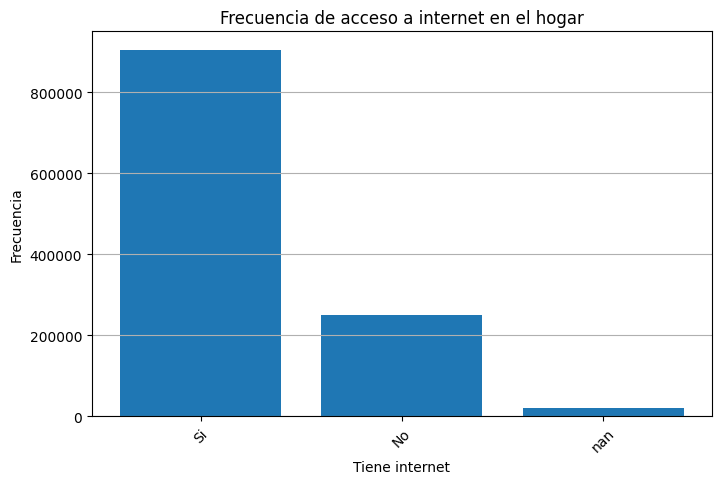

In [0]:
freq_internet = icfes["FAMI_TIENEINTERNET"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
plt.bar(freq_internet.index.astype(str), freq_internet.values)
plt.title("Frecuencia de acceso a internet en el hogar")
plt.xlabel("Tiene internet")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Se visualiza la evolución temporal del puntaje global promedio del ICFES por municipio, permitiendo comparar tendencias entre los territorios analizados.

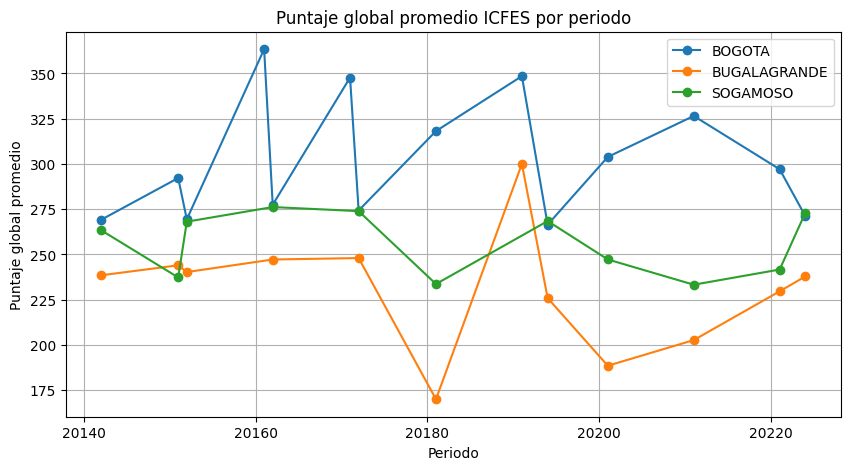

In [0]:
plt.figure(figsize=(10, 5))

for municipio in icfes_tiempo["municipio_objetivo"].dropna().unique():
    datos = icfes_tiempo[icfes_tiempo["municipio_objetivo"] == municipio].sort_values("PERIODO")
    plt.plot(datos["PERIODO"], datos["punt_global_prom"], marker="o", label=municipio)

plt.title("Puntaje global promedio ICFES por periodo")
plt.xlabel("Periodo")
plt.ylabel("Puntaje global promedio")
plt.legend()
plt.grid(True)
plt.show()

Se analizan las tendencias temporales de los puntajes promedio en matemáticas, lectura crítica e inglés por municipio, comparando su comportamiento a lo largo del tiempo.

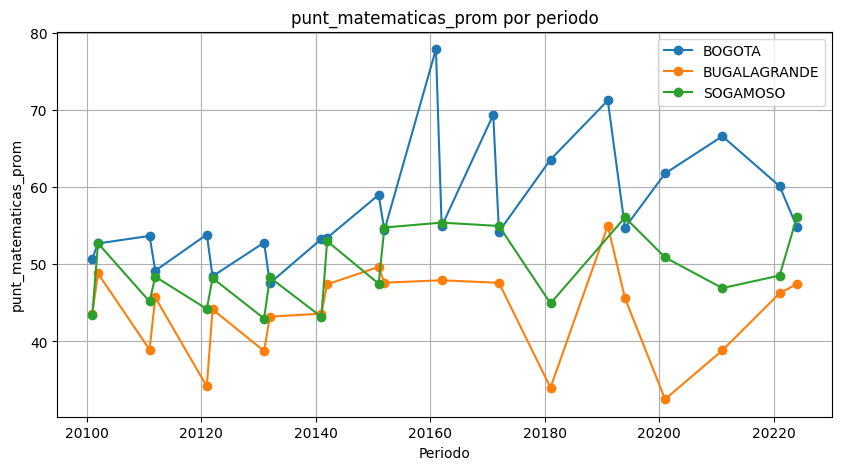

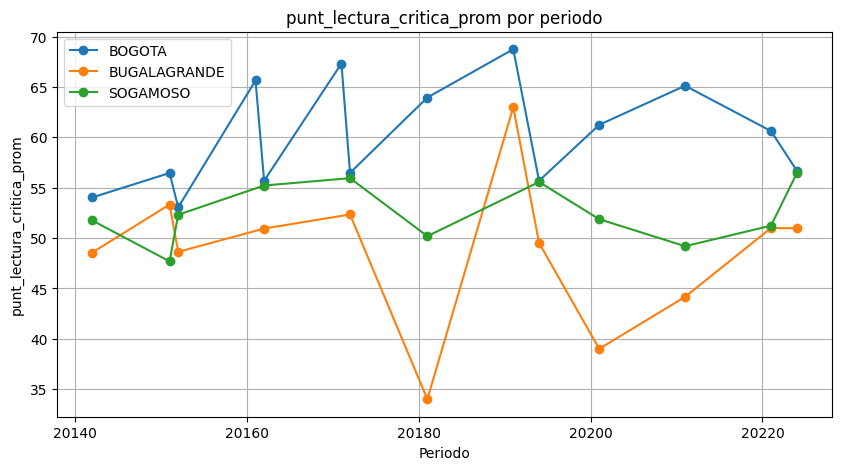

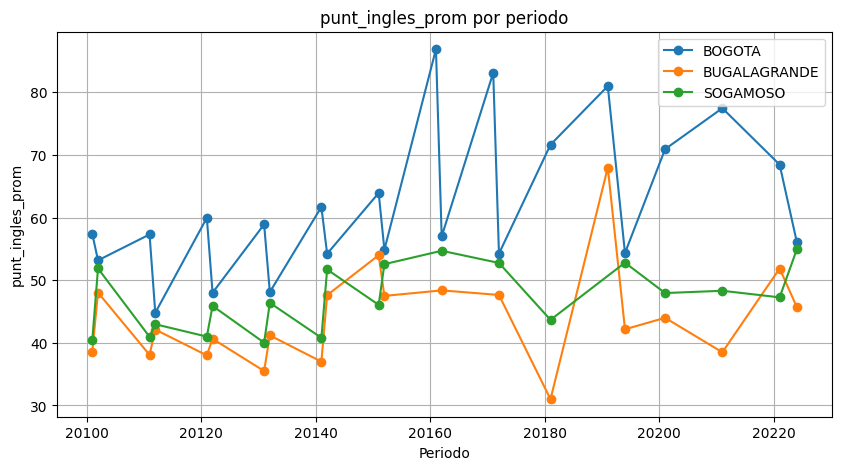

In [0]:
metricas = [
    "punt_matematicas_prom",
    "punt_lectura_critica_prom",
    "punt_ingles_prom"
]

for metrica in metricas:
    plt.figure(figsize=(10, 5))
    
    for municipio in icfes_tiempo["municipio_objetivo"].dropna().unique():
        datos = icfes_tiempo[icfes_tiempo["municipio_objetivo"] == municipio].sort_values("PERIODO")
        plt.plot(datos["PERIODO"], datos[metrica], marker="o", label=municipio)
    
    plt.title(f"{metrica} por periodo")
    plt.xlabel("Periodo")
    plt.ylabel(metrica)
    plt.legend()
    plt.grid(True)
    plt.show()

Se compara el puntaje global promedio del ICFES entre municipios, identificando diferencias en el desempeño académico general.

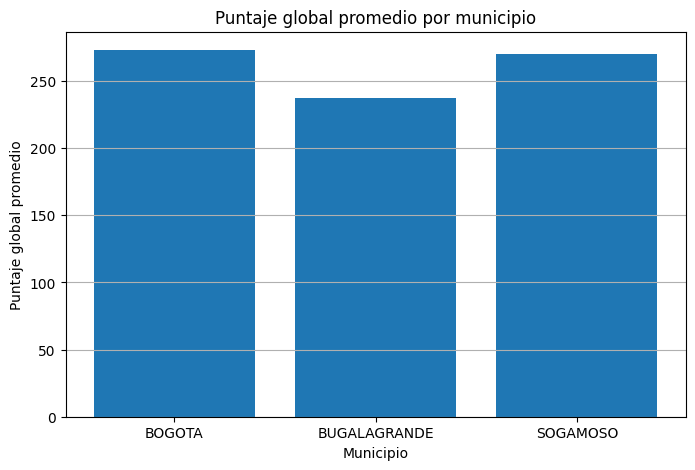

In [0]:
plt.figure(figsize=(8, 5))
plt.bar(icfes_mpio["municipio_objetivo"], icfes_mpio["punt_global_prom"])
plt.title("Puntaje global promedio por municipio")
plt.xlabel("Municipio")
plt.ylabel("Puntaje global promedio")
plt.grid(axis="y")
plt.show()

Se comparan los puntajes promedio por área (matemáticas, lectura crítica e inglés) entre municipios, identificando diferencias en el desempeño académico específico.

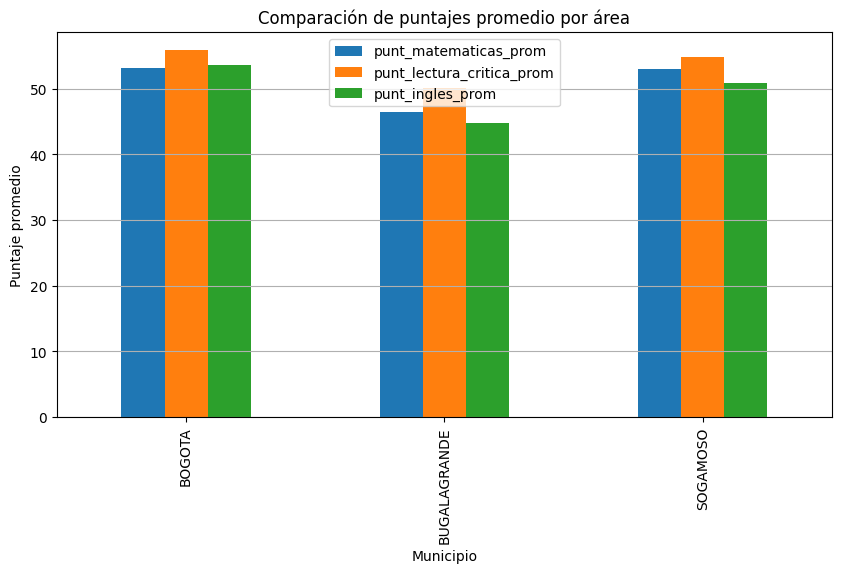

In [0]:
comparativo = icfes_mpio.set_index("municipio_objetivo")[
    ["punt_matematicas_prom", "punt_lectura_critica_prom", "punt_ingles_prom"]
]

comparativo.plot(kind="bar", figsize=(10, 5))
plt.title("Comparación de puntajes promedio por área")
plt.xlabel("Municipio")
plt.ylabel("Puntaje promedio")
plt.grid(axis="y")
plt.show()

Se analiza la distribución del puntaje global del ICFES mediante un histograma, evaluando su forma, dispersión y posibles valores atípicos.

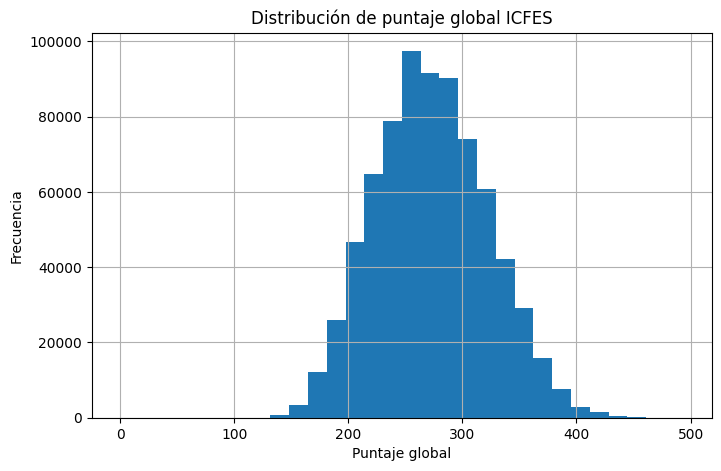

In [0]:
plt.figure(figsize=(8, 5))
plt.hist(icfes["PUNT_GLOBAL"].dropna(), bins=30)
plt.title("Distribución de puntaje global ICFES")
plt.xlabel("Puntaje global")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

Se analiza la distribución del estrato socioeconómico de los estudiantes, evaluando su frecuencia para caracterizar el contexto socioeconómico.

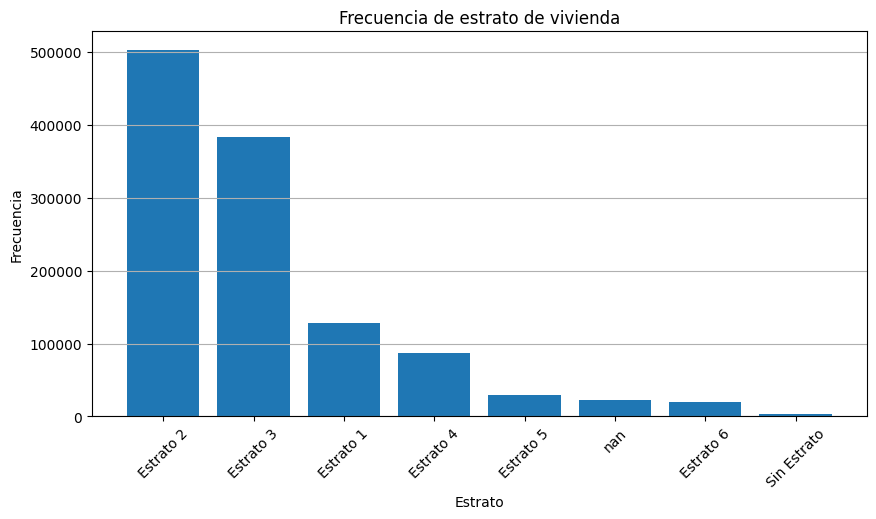

In [0]:
freq_estrato = icfes["FAMI_ESTRATOVIVIENDA"].value_counts(dropna=False)

plt.figure(figsize=(10, 5))
plt.bar(freq_estrato.index.astype(str), freq_estrato.values)
plt.title("Frecuencia de estrato de vivienda")
plt.xlabel("Estrato")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Se analiza la frecuencia de acceso a internet en el hogar, evaluando la disponibilidad de conectividad como factor relevante en el contexto educativo.

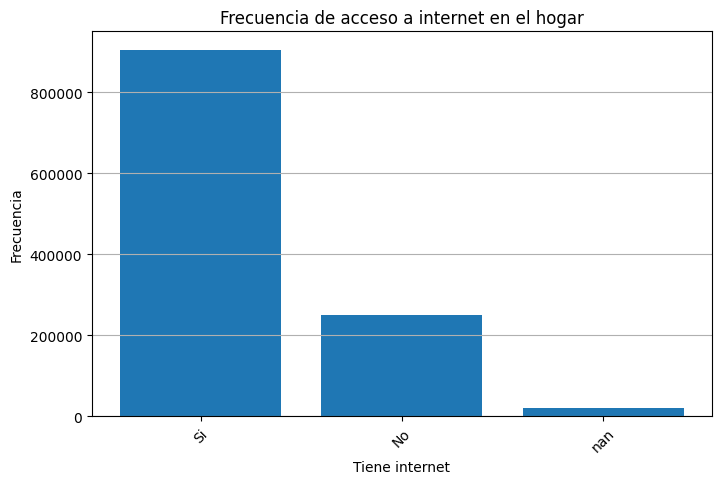

In [0]:
freq_internet = icfes["FAMI_TIENEINTERNET"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
plt.bar(freq_internet.index.astype(str), freq_internet.values)
plt.title("Frecuencia de acceso a internet en el hogar")
plt.xlabel("Tiene internet")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Se analiza la frecuencia de disponibilidad de computador en el hogar, evaluando este recurso como factor asociado al desempeño académico.

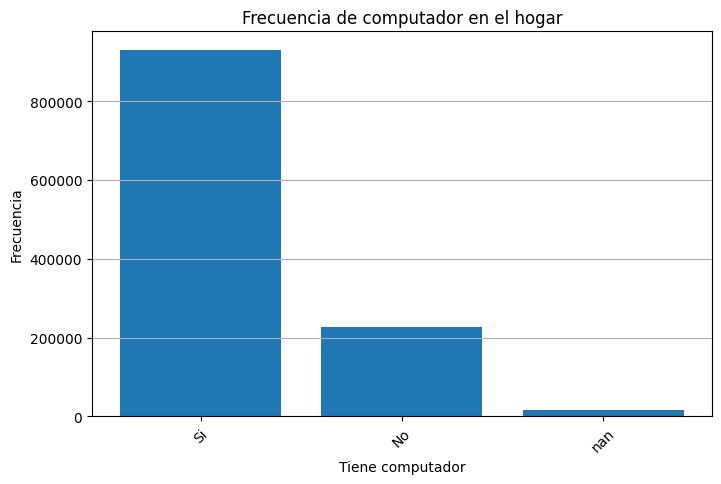

In [0]:
freq_pc = icfes["FAMI_TIENECOMPUTADOR"].value_counts(dropna=False)

plt.figure(figsize=(8, 5))
plt.bar(freq_pc.index.astype(str), freq_pc.values)
plt.title("Frecuencia de computador en el hogar")
plt.xlabel("Tiene computador")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

Se analiza la distribución de la clasificación del Sisbén, evaluando la concentración de la población en los distintos niveles socioeconómicos.

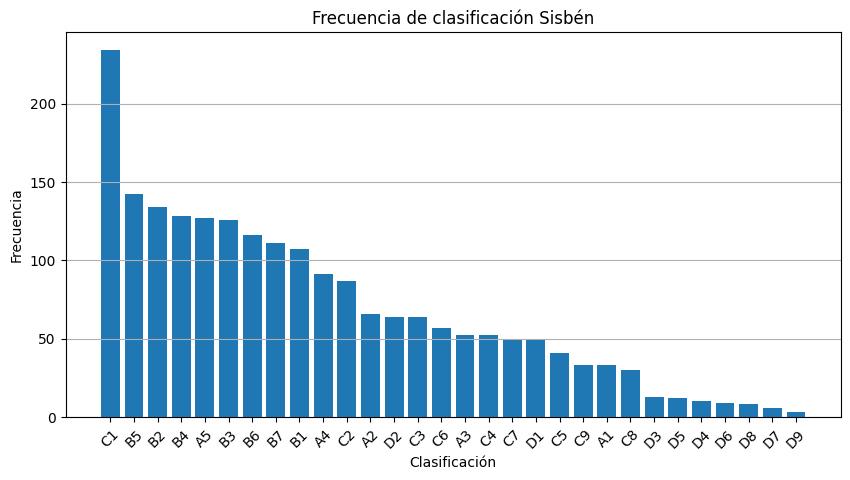

In [0]:
if "clasificacion" in sisben.columns:
    freq_clas = sisben["clasificacion"].value_counts(dropna=False)

    plt.figure(figsize=(10, 5))
    plt.bar(freq_clas.index.astype(str), freq_clas.values)
    plt.title("Frecuencia de clasificación Sisbén")
    plt.xlabel("Clasificación")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

Se analiza la distribución de la variable PER016, evaluando la condición de estudio de la población dentro del dataset del Sisbén.

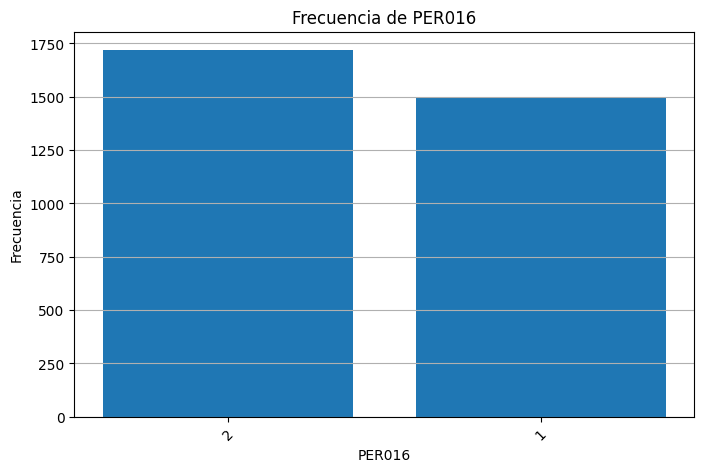

In [0]:
if "per016" in sisben.columns:
    freq_estudia = sisben["per016"].value_counts(dropna=False)

    plt.figure(figsize=(8, 5))
    plt.bar(freq_estudia.index.astype(str), freq_estudia.values)
    plt.title("Frecuencia de PER016")
    plt.xlabel("PER016")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

Se analiza la distribución del puntaje global del ICFES por municipio mediante diagramas de caja, identificando dispersión, mediana y valores atípicos.

/home/spark-78bdbe4c-5c1b-4084-9565-c6/.ipykernel/2719/command-5271872139818133-3161178705:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=labels_box)


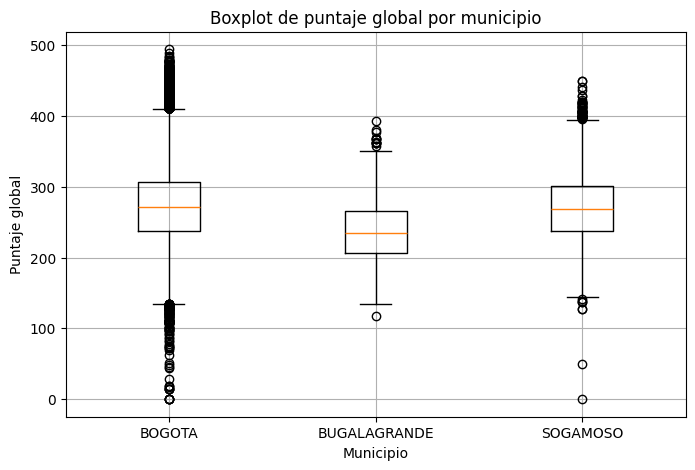

In [0]:
datos_box = [
    icfes[icfes["municipio_objetivo"] == m]["PUNT_GLOBAL"].dropna()
    for m in icfes["municipio_objetivo"].dropna().unique()
]

labels_box = list(icfes["municipio_objetivo"].dropna().unique())

plt.figure(figsize=(8, 5))
plt.boxplot(datos_box, labels=labels_box)
plt.title("Boxplot de puntaje global por municipio")
plt.xlabel("Municipio")
plt.ylabel("Puntaje global")
plt.grid(True)
plt.show()

Se analiza la distribución del puntaje global del ICFES por estrato socioeconómico mediante diagramas de caja, identificando diferencias en desempeño y variabilidad entre grupos.

/home/spark-78bdbe4c-5c1b-4084-9565-c6/.ipykernel/2719/command-5271872139818134-3383313726:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=[str(e) for e in sorted(estratos_validos)])


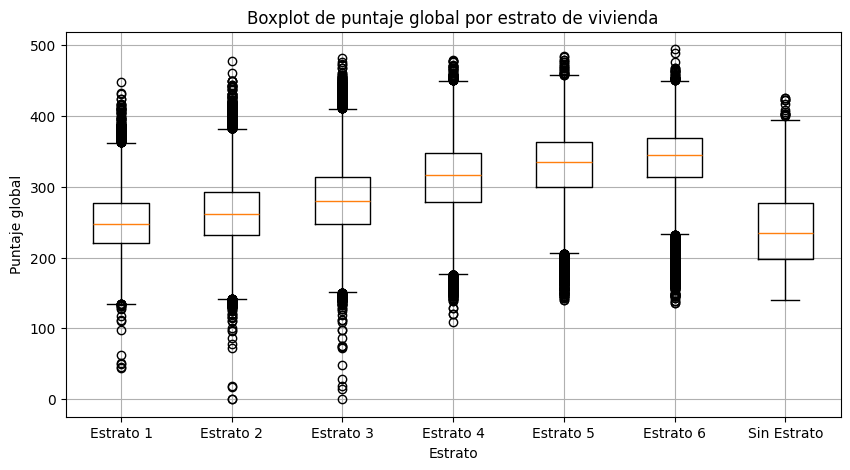

In [0]:
estratos_validos = icfes["FAMI_ESTRATOVIVIENDA"].dropna().unique()

datos_box = [
    icfes[icfes["FAMI_ESTRATOVIVIENDA"] == e]["PUNT_GLOBAL"].dropna()
    for e in sorted(estratos_validos)
]

plt.figure(figsize=(10, 5))
plt.boxplot(datos_box, labels=[str(e) for e in sorted(estratos_validos)])
plt.title("Boxplot de puntaje global por estrato de vivienda")
plt.xlabel("Estrato")
plt.ylabel("Puntaje global")
plt.grid(True)
plt.show()

Se analiza la relación entre la cobertura neta educativa y el puntaje global promedio del ICFES mediante un gráfico de dispersión, identificando posibles asociaciones entre ambas variables.

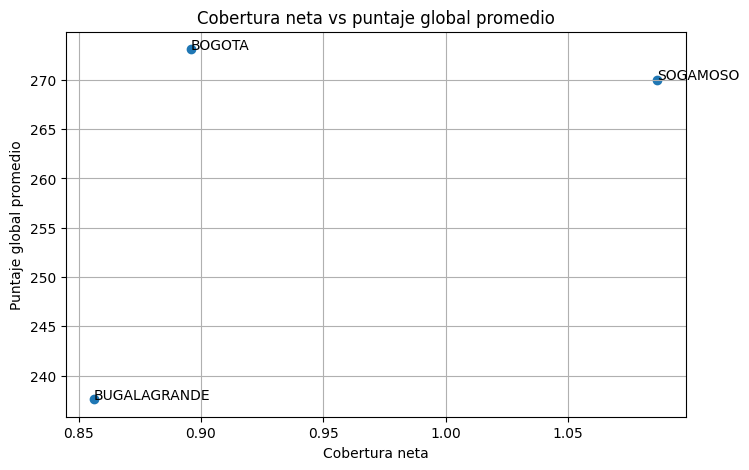

In [0]:
datos_scatter = base_analisis.dropna(subset=["cobertura_neta", "punt_global_prom"])

plt.figure(figsize=(8, 5))
plt.scatter(datos_scatter["cobertura_neta"], datos_scatter["punt_global_prom"])

for _, row in datos_scatter.iterrows():
    plt.text(row["cobertura_neta"], row["punt_global_prom"], str(row["municipio_objetivo"]))

plt.title("Cobertura neta vs puntaje global promedio")
plt.xlabel("Cobertura neta")
plt.ylabel("Puntaje global promedio")
plt.grid(True)
plt.show()

Se analiza la relación entre la tasa de deserción y el puntaje global promedio del ICFES mediante un gráfico de dispersión, evaluando su posible asociación.

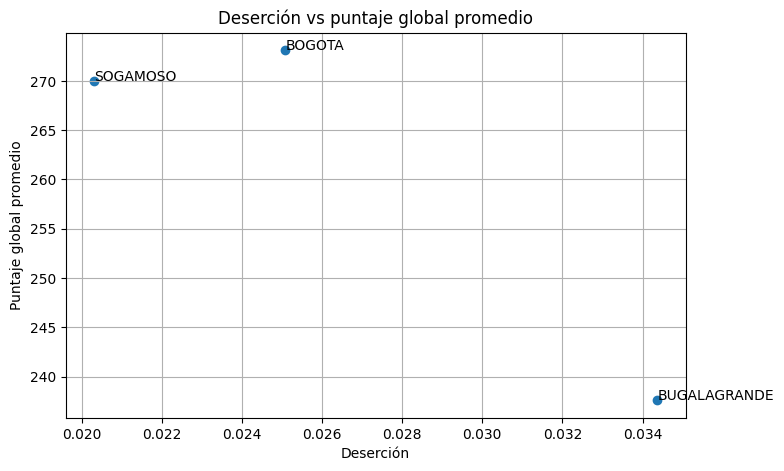

In [0]:
datos_scatter = base_analisis.dropna(subset=["desercion", "punt_global_prom"])

plt.figure(figsize=(8, 5))
plt.scatter(datos_scatter["desercion"], datos_scatter["punt_global_prom"])

for _, row in datos_scatter.iterrows():
    plt.text(row["desercion"], row["punt_global_prom"], str(row["municipio_objetivo"]))

plt.title("Deserción vs puntaje global promedio")
plt.xlabel("Deserción")
plt.ylabel("Puntaje global promedio")
plt.grid(True)
plt.show()

Se analiza la relación entre el indicador H_5 promedio y el puntaje global promedio del ICFES mediante un gráfico de dispersión, evaluando su posible asociación.

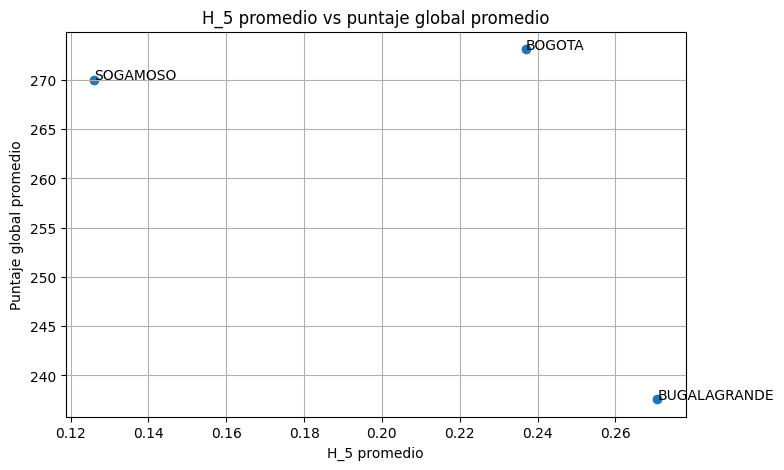

In [0]:
datos_scatter = base_analisis.dropna(subset=["h5_prom", "punt_global_prom"])

plt.figure(figsize=(8, 5))
plt.scatter(datos_scatter["h5_prom"], datos_scatter["punt_global_prom"])

for _, row in datos_scatter.iterrows():
    plt.text(row["h5_prom"], row["punt_global_prom"], str(row["municipio_objetivo"]))

plt.title("H_5 promedio vs puntaje global promedio")
plt.xlabel("H_5 promedio")
plt.ylabel("Puntaje global promedio")
plt.grid(True)
plt.show()

Se analiza la relación entre la proporción de población en grupo A/B y el puntaje global promedio del ICFES, evaluando su posible asociación con el desempeño académico.

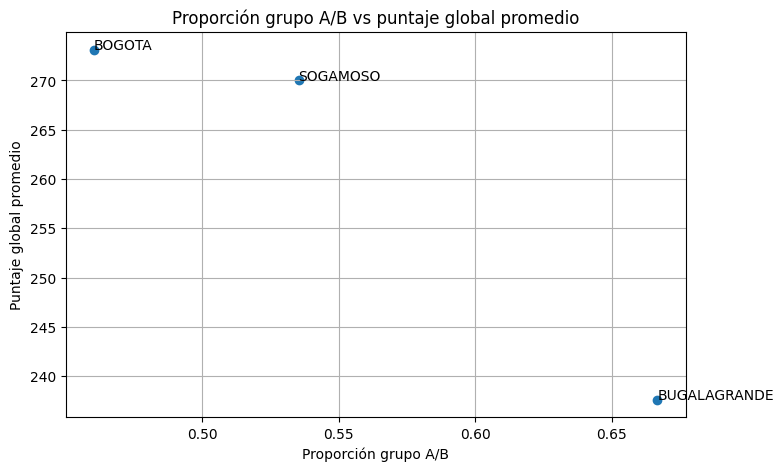

In [0]:
if "grupo_ab_prop" in base_analisis.columns:
    datos_scatter = base_analisis.dropna(subset=["grupo_ab_prop", "punt_global_prom"])

    plt.figure(figsize=(8, 5))
    plt.scatter(datos_scatter["grupo_ab_prop"], datos_scatter["punt_global_prom"])

    for _, row in datos_scatter.iterrows():
        plt.text(row["grupo_ab_prop"], row["punt_global_prom"], str(row["municipio_objetivo"]))

    plt.title("Proporción grupo A/B vs puntaje global promedio")
    plt.xlabel("Proporción grupo A/B")
    plt.ylabel("Puntaje global promedio")
    plt.grid(True)
    plt.show()

Se comparan los indicadores socioeconómicos promedio entre municipios, permitiendo identificar diferencias en condiciones sociales y su posible relación con el desempeño educativo.

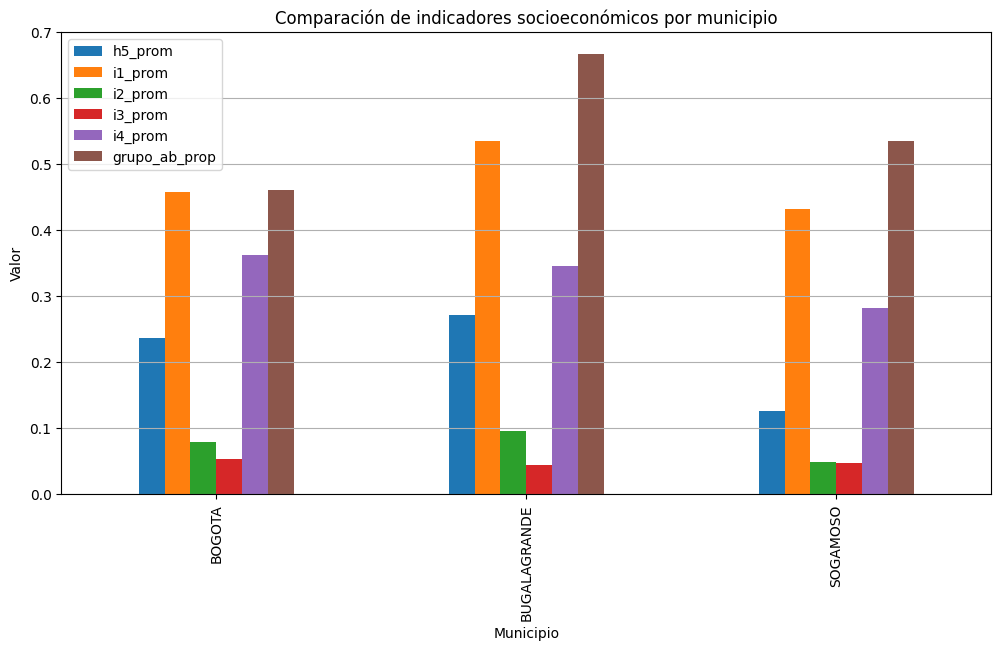

In [0]:
vars_soc = [c for c in ["h5_prom", "i1_prom", "i2_prom", "i3_prom", "i4_prom", "grupo_ab_prop"] if c in base_analisis.columns]

comparativo_soc = base_analisis.set_index("municipio_objetivo")[vars_soc]
comparativo_soc.plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de indicadores socioeconómicos por municipio")
plt.xlabel("Municipio")
plt.ylabel("Valor")
plt.grid(axis="y")
plt.show()

Se construye una matriz de correlación para identificar la relación entre variables educativas, socioeconómicas y de contexto, permitiendo detectar asociaciones positivas o negativas relevantes para el análisis.

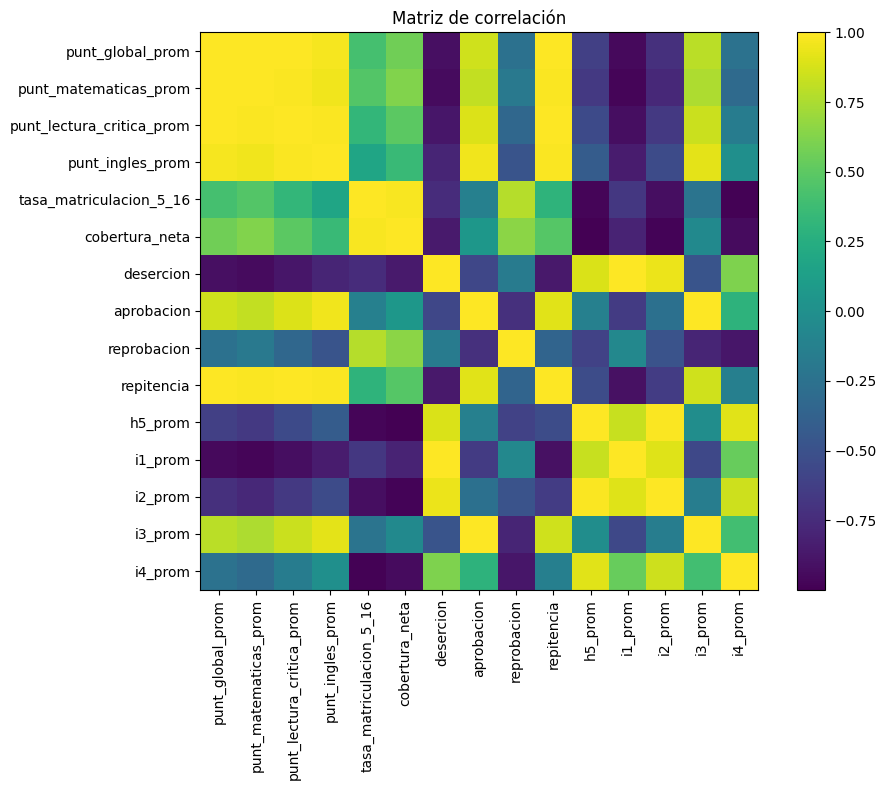

In [0]:
cols_corr = [
    "punt_global_prom",
    "punt_matematicas_prom",
    "punt_lectura_critica_prom",
    "punt_ingles_prom",
    "tasa_matriculacion_5_16",
    "cobertura_neta",
    "desercion",
    "aprobacion",
    "reprobacion",
    "repitencia",
    "h5_prom",
    "i1_prom",
    "i2_prom",
    "i3_prom",
    "i4_prom"
]

cols_corr = [c for c in cols_corr if c in base_analisis.columns]

corr = base_analisis[cols_corr].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()